[******                12%                       ]  6 of 48 completed

[*********************100%***********************]  48 of 48 completed


Fetching P/E ratios...
Running backtest...


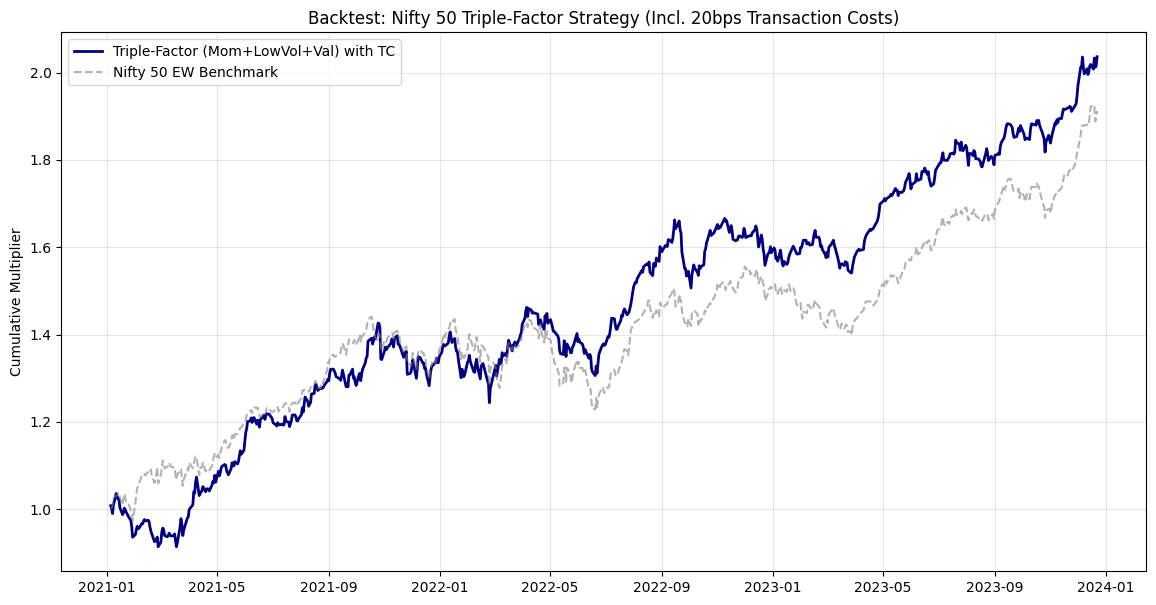

Final Strategy Return: 2.04x
Final Benchmark Return: 1.91x


In [25]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Define Universe (Full Nifty 50)
nifty50_tickers = [
    'ADANIENT.NS', 'ADANIPORTS.NS', 'APOLLOHOSP.NS', 'ASIANPAINT.NS', 'AXISBANK.NS',
    'BAJAJ-AUTO.NS', 'BAJFINANCE.NS', 'BAJAJFINSV.NS', 'BPCL.NS', 'BHARTIARTL.NS',
    'BRITANNIA.NS', 'CIPLA.NS', 'COALINDIA.NS', 'DIVISLAB.NS', 'DRREDDY.NS',
    'EICHERMOT.NS', 'GRASIM.NS', 'HCLTECH.NS', 'HDFCBANK.NS', 'HDFCLIFE.NS',
    'HEROMOTOCO.NS', 'HINDALCO.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'ITC.NS',
    'INDUSINDBK.NS', 'INFY.NS', 'JSWSTEEL.NS', 'KOTAKBANK.NS',
    'LT.NS', 'M&M.NS', 'MARUTI.NS', 'NTPC.NS', 'NESTLEIND.NS', 'ONGC.NS',
    'POWERGRID.NS', 'RELIANCE.NS', 'SBILIFE.NS', 'SBIN.NS', 'SUNPHARMA.NS',
    'TCS.NS', 'TATACONSUM.NS', 'TATASTEEL.NS', 'TECHM.NS',
    'TITAN.NS', 'ULTRACEMCO.NS', 'UPL.NS', 'WIPRO.NS'
]

# --- Step 1: Data Acquisition ---
print("Downloading historical price data...")
raw_data = yf.download(nifty50_tickers, start='2020-01-01', end='2024-01-01', auto_adjust=False)
data = raw_data['Adj Close'] if 'Adj Close' in raw_data.columns.levels[0] else raw_data['Close']
returns = data.pct_change().dropna(how='all')

# --- Step 2: Fetch P/E Ratios (Value Factor) ---
print("Fetching P/E ratios...")
pe_ratios = {}
for ticker in nifty50_tickers:
    try:
        t = yf.Ticker(ticker)
        pe_ratios[ticker] = t.info.get('trailingPE', np.nan)
    except:
        pe_ratios[ticker] = np.nan

pe_series = pd.Series(pe_ratios).fillna(pd.Series(pe_ratios).median())

# --- Step 3: Factor Calculation ---
# Momentum (12-month)
mom = returns.rolling(window=252).apply(lambda x: (1 + x).prod() - 1).dropna(how='all')
z_mom = (mom.sub(mom.mean(axis=1), axis=0)).div(mom.std(axis=1), axis=0)

# Volatility (3-month)
vol = returns.rolling(window=63).std().dropna(how='all')
z_vol = (vol.sub(vol.mean(axis=1), axis=0)).div(vol.std(axis=1), axis=0)

# Value (P/E Z-score)
z_pe = (pe_series - pe_series.mean()) / pe_series.std()
z_pe_df = pd.DataFrame(np.tile(z_pe.values, (len(z_mom), 1)), index=z_mom.index, columns=z_mom.columns)

# Triple Factor Composite Score
final_score = (z_mom - z_vol - z_pe_df).dropna(how='all')

# --- Step 4: Backtest with Transaction Costs ---
print("Running backtest...")
strategy_returns = []
portfolio_size = 5
rebalance_dates = final_score.index[::21]
transaction_cost_bps = 20
previous_selected = pd.Index([])

for i in range(len(rebalance_dates) - 1):
    reb_date = rebalance_dates[i]
    next_reb_date = rebalance_dates[i+1]
    scores = final_score.loc[reb_date].dropna()

    if not scores.empty:
        selected = scores.nlargest(portfolio_size).index
        # Transaction Cost Calculation
        num_trades = len(previous_selected.difference(selected)) + len(selected.difference(previous_selected))
        cost_pct = (num_trades / portfolio_size) * (transaction_cost_bps / 10000)

        period_rets = returns.loc[reb_date:next_reb_date, selected].iloc[1:].mean(axis=1)
        if not period_rets.empty:
            period_rets.iloc[0] -= cost_pct
        strategy_returns.append(period_rets)
        previous_selected = selected

strategy_df = pd.concat(strategy_returns)
strategy_df = strategy_df[~strategy_df.index.duplicated()]
cum_strat = (1 + strategy_df).cumprod()
bench_returns = returns.loc[strategy_df.index].mean(axis=1)
cum_bench = (1 + bench_returns).cumprod()

# --- Step 5: Visualization ---
plt.figure(figsize=(14, 7))
plt.plot(cum_strat, label='Triple-Factor (Mom+LowVol+Val) with TC', color='navy', lw=2)
plt.plot(cum_bench, label='Nifty 50 EW Benchmark', color='gray', alpha=0.6, ls='--')
plt.title('Backtest: Nifty 50 Triple-Factor Strategy (Incl. 20bps Transaction Costs)')
plt.ylabel('Cumulative Multiplier')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Final Strategy Return: {cum_strat.iloc[-1]:.2f}x")
print(f"Final Benchmark Return: {cum_bench.iloc[-1]:.2f}x")

In [26]:
import time

# 7. Fetch P/E Ratios (Value Factor)
pe_ratios = {}
print(f"Fetching P/E ratios for {len(nifty50_tickers)} tickers...")

for ticker in nifty50_tickers:
    try:
        t = yf.Ticker(ticker)
        # trailingPE is a common metric for Value
        pe = t.info.get('trailingPE', np.nan)
        pe_ratios[ticker] = pe
    except Exception as e:
        pe_ratios[ticker] = np.nan

# Convert to Series and clean
pe_series = pd.Series(pe_ratios)
print("\nFirst 5 P/E Ratios:")
print(pe_series.head())

# Handle missing values by filling with the median of the universe
pe_series = pe_series.fillna(pe_series.median())


Fetching P/E ratios for 48 tickers...

First 5 P/E Ratios:
ADANIENT.NS      52.628754
ADANIPORTS.NS    28.985506
APOLLOHOSP.NS    61.351448
ASIANPAINT.NS    54.349930
AXISBANK.NS      13.698661
dtype: float64


In [27]:
z_pe = (pe_series - pe_series.mean()) / pe_series.std()

# Since PE is static (current snapshot), we broadcast it across our backtest dates
# A more advanced model would use historical point-in-time PE data
z_pe_df = pd.DataFrame(np.tile(z_pe.values, (len(z_mom), 1)),
                       index=z_mom.index,
                       columns=z_mom.columns)

# Triple Factor Score: High Momentum + Low Volatility + Low PE (High Value)
# We subtract z_vol and z_pe because lower is better for those factors
composite_score_v2 = (z_mom - z_vol - z_pe_df).dropna(how='all')

print("Updated composite score with Value factor calculated.")
display(composite_score_v2.tail())

Updated composite score with Value factor calculated.


Ticker,ADANIENT.NS,ADANIPORTS.NS,APOLLOHOSP.NS,ASIANPAINT.NS,AXISBANK.NS,BAJAJ-AUTO.NS,BAJAJFINSV.NS,BAJFINANCE.NS,BHARTIARTL.NS,BPCL.NS,...,SBIN.NS,SUNPHARMA.NS,TATACONSUM.NS,TATASTEEL.NS,TCS.NS,TECHM.NS,TITAN.NS,ULTRACEMCO.NS,UPL.NS,WIPRO.NS
Date,,,,,,,,,,,,,,,,,,,,,
2023-12-22,-7.633451,-3.336979,-1.830351,-1.046543,0.432521,2.515982,-0.890538,-0.844628,2.062119,-0.374611,...,0.191481,0.665701,1.945497,-1.316919,0.728465,0.232654,-0.643545,0.626841,-1.695944,0.021880
2023-12-26,-7.544039,-3.274088,-1.789643,-0.969501,0.406127,2.616896,-0.975485,-1.028806,2.025225,-0.320268,...,0.297481,0.624801,1.897681,-1.384371,0.685468,0.175653,-0.651361,0.664311,-1.696074,0.051285
2023-12-27,-7.629726,-3.462100,-1.779025,-0.963283,0.398816,2.661104,-1.003379,-1.051957,1.967022,-0.232257,...,0.373901,0.722226,1.904050,-1.347494,0.778295,0.163394,-0.667288,0.697830,-1.675585,0.168638
2023-12-28,-7.688818,-3.496343,-1.731409,-0.989630,0.330388,2.502062,-0.940389,-0.735879,2.005952,-0.217343,...,0.357609,0.687873,1.990821,-1.350855,0.637808,0.154131,-0.710529,0.557905,-1.582848,0.108449
2023-12-29,-7.515089,-3.344501,-1.978270,-0.955693,0.380757,2.616802,-0.845624,-0.636078,2.064408,-0.490445,...,0.323701,0.579735,1.918209,-1.225645,0.581774,0.056236,-0.747555,0.724111,-1.618567,0.108651


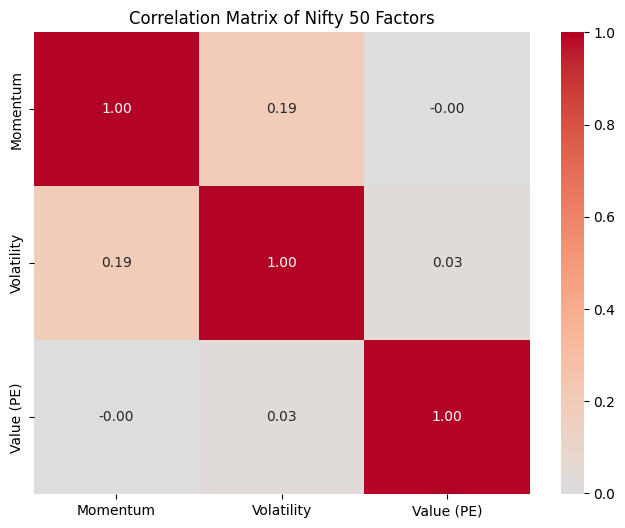

,Momentum,Volatility,Value (PE)
Momentum,1.000000,0.193426,-0.001790
Volatility,0.193426,1.000000,0.032245
Value (PE),-0.001790,0.032245,1.000000


In [28]:
import seaborn as sns

# 9. Factor Correlation Analysis
# Align indices to ensure we are looking at overlapping valid data points
common_index = z_mom.dropna(how='all').index.intersection(z_pe_df.index)

mom_valid = z_mom.loc[common_index].values.flatten()
vol_valid = z_vol.loc[common_index].values.flatten()
pe_valid = z_pe_df.loc[common_index].values.flatten()

factor_data = pd.DataFrame({
    'Momentum': mom_valid,
    'Volatility': vol_valid,
    'Value (PE)': pe_valid
}).dropna()

corr_matrix = factor_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Nifty 50 Factors')
plt.show()

display(corr_matrix)

In [29]:
# Get the top 5 stock picks for the most recent date
latest_date = final_score.index[-1]
current_picks = final_score.loc[latest_date].nlargest(5)

print(f"Top 5 Stock Picks as of {latest_date.date()}:")
display(current_picks)

# Optional: display the raw factors for these top picks for transparency
top_tickers = current_picks.index
factor_breakdown = pd.DataFrame({
    'Composite Score': current_picks,
    'Momentum Z-Score': z_mom.loc[latest_date, top_tickers],
    'Volatility Z-Score': z_vol.loc[latest_date, top_tickers],
    'Value (PE) Z-Score': z_pe_df.loc[latest_date, top_tickers]
})

print("\nFactor Breakdown for Top Picks:")
display(factor_breakdown)

Top 5 Stock Picks as of 2023-12-29:


,2023-12-29
Ticker,
BAJAJ-AUTO.NS,2.616802
POWERGRID.NS,2.392763
ITC.NS,2.334938
ONGC.NS,2.121993
BHARTIARTL.NS,2.064408



Factor Breakdown for Top Picks:


,Composite Score,Momentum Z-Score,Volatility Z-Score,Value (PE) Z-Score
Ticker,,,,
BAJAJ-AUTO.NS,2.616802,2.670912,0.302171,-0.248061
POWERGRID.NS,2.392763,1.113314,-0.314871,-0.964579
ITC.NS,2.334938,0.606660,-0.865477,-0.862802
ONGC.NS,2.121993,0.941165,0.082872,-1.263700
BHARTIARTL.NS,2.064408,-0.040512,-0.896189,-1.208730


/tmp/ipykernel_897/4172709929.py:23: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(nifty50_tickers, start='2020-01-01', end='2024-01-01')['Close'] # Changed 'Adj Close' to 'Close'
[*********************100%***********************]  48 of 48 completed


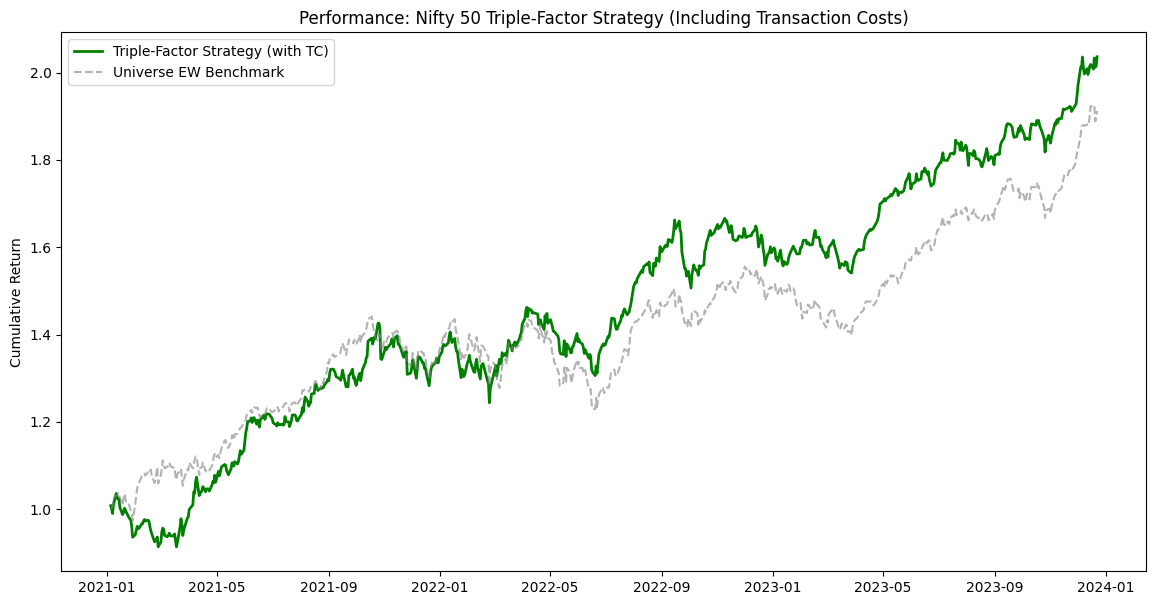

In [30]:
import time
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Data Acquisition ---
# Re-defining tickers to ensure they are available in this scope
nifty50_tickers = [
    'ADANIENT.NS', 'ADANIPORTS.NS', 'APOLLOHOSP.NS', 'ASIANPAINT.NS', 'AXISBANK.NS',
    'BAJAJ-AUTO.NS', 'BAJFINANCE.NS', 'BAJAJFINSV.NS', 'BPCL.NS', 'BHARTIARTL.NS',
    'BRITANNIA.NS', 'CIPLA.NS', 'COALINDIA.NS', 'DIVISLAB.NS', 'DRREDDY.NS',
    'EICHERMOT.NS', 'GRASIM.NS', 'HCLTECH.NS', 'HDFCBANK.NS', 'HDFCLIFE.NS',
    'HEROMOTOCO.NS', 'HINDALCO.NS', 'HINDUNILVR.NS', 'ICICIBANK.NS', 'ITC.NS',
    'INDUSINDBK.NS', 'INFY.NS', 'JSWSTEEL.NS', 'KOTAKBANK.NS',
    'LT.NS', 'M&M.NS', 'MARUTI.NS', 'NTPC.NS', 'NESTLEIND.NS', 'ONGC.NS',
    'POWERGRID.NS', 'RELIANCE.NS', 'SBILIFE.NS', 'SBIN.NS', 'SUNPHARMA.NS',
    'TCS.NS', 'TATACONSUM.NS', 'TATASTEEL.NS', 'TECHM.NS',
    'TITAN.NS', 'ULTRACEMCO.NS', 'UPL.NS', 'WIPRO.NS'
]

print("Downloading historical data...")
data = yf.download(nifty50_tickers, start='2020-01-01', end='2024-01-01')['Close'] # Changed 'Adj Close' to 'Close'
returns = data.pct_change().dropna(how='all')

# --- Step 2: Factor Calculation ---
lookback_mom = 252
mom = returns.rolling(window=lookback_mom).apply(lambda x: (1 + x).prod() - 1).dropna(how='all')
z_mom = (mom.sub(mom.mean(axis=1), axis=0)).div(mom.std(axis=1), axis=0)

lookback_vol = 63
vol = returns.rolling(window=lookback_vol).std().dropna(how='all')
z_vol = (vol.sub(vol.mean(axis=1), axis=0)).div(vol.std(axis=1), axis=0)

# Assuming z_pe_df was defined previously; if not, re-calculate or broadcast pe_series
composite_score_v2 = (z_mom - z_vol - z_pe_df).dropna(how='all')

# --- Step 3: Backtest with Transaction Costs ---
strategy_returns_v2 = []
portfolio_size = 5
rebalance_dates = composite_score_v2.index[::21] # Monthly rebalance
transaction_cost_basis_points = 20
previous_selected = pd.Index([])

for i in range(len(rebalance_dates) - 1):
    reb_date = rebalance_dates[i]
    next_reb_date = rebalance_dates[i+1]
    scores = composite_score_v2.loc[reb_date].dropna()

    if not scores.empty:
        selected = scores.nlargest(portfolio_size).index
        stocks_to_sell = previous_selected.difference(selected)
        stocks_to_buy = selected.difference(previous_selected)
        num_trades = len(stocks_to_sell) + len(stocks_to_buy)
        cost_percentage = (num_trades / portfolio_size) * (transaction_cost_basis_points / 10000)

        period_rets = returns.loc[reb_date:next_reb_date, selected].iloc[1:].mean(axis=1)
        if not period_rets.empty:
            period_rets.iloc[0] -= cost_percentage
        strategy_returns_v2.append(period_rets)
        previous_selected = selected

strategy_df_v2 = pd.concat(strategy_returns_v2)
strategy_df_v2 = strategy_df_v2[~strategy_df_v2.index.duplicated()]
cum_strat_v2 = (1 + strategy_df_v2).cumprod()
bench_returns = returns.loc[strategy_df_v2.index].mean(axis=1)
cum_bench = (1 + bench_returns).cumprod()

plt.figure(figsize=(14, 7))
plt.plot(cum_strat_v2, label='Triple-Factor Strategy (with TC)', color='green', linewidth=2)
plt.plot(cum_bench, label='Universe EW Benchmark', color='gray', alpha=0.6, linestyle='--')
plt.title('Performance: Nifty 50 Triple-Factor Strategy (Including Transaction Costs)')
plt.ylabel('Cumulative Return')
plt.legend()
plt.show()

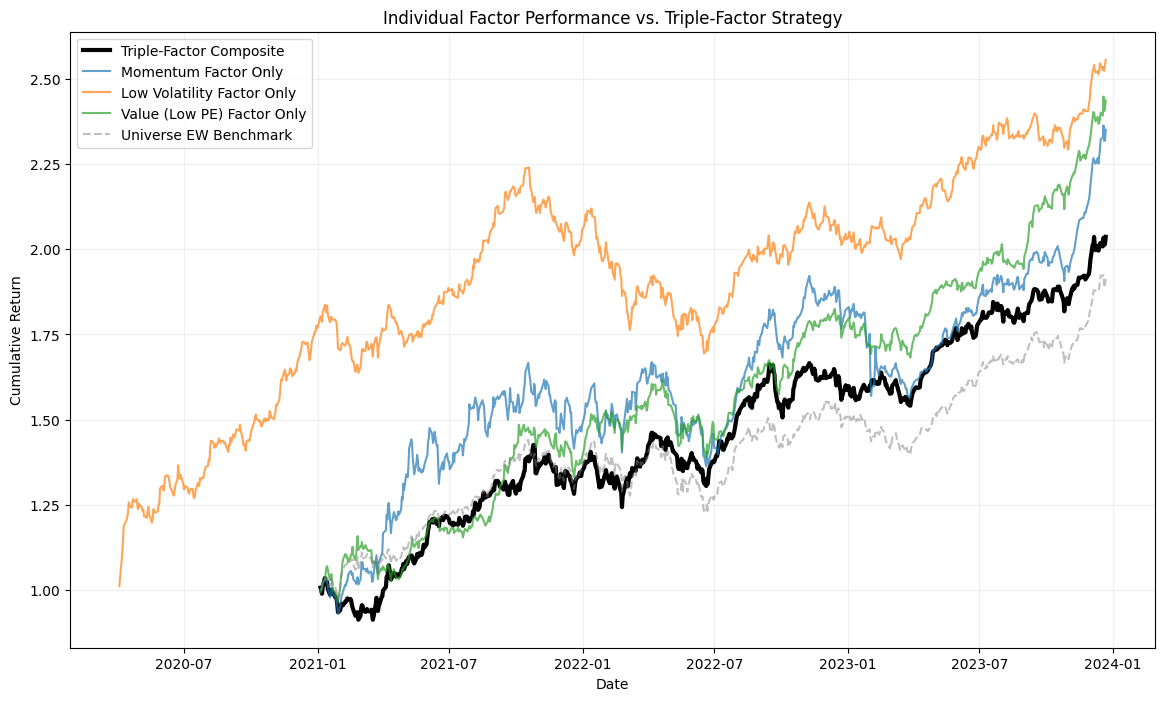

Final Returns:
Composite: 2.04x
Momentum: 2.35x
Low Vol: 2.56x
Value: 2.44x


In [31]:
def backtest_single_factor(factor_df, portfolio_size=5):
    returns_list = []
    rebalance_dates = factor_df.index[::21]
    for i in range(len(rebalance_dates) - 1):
        reb_date = rebalance_dates[i]
        next_reb_date = rebalance_dates[i+1]
        scores = factor_df.loc[reb_date].dropna()
        if not scores.empty:
            # For Momentum, we want largest. For Vol and PE, we want smallest (highest Value)
            # However, z_vol and z_pe_df were already oriented so that higher composite = better
            # For consistency with the composite score (z_mom - z_vol - z_pe_df):
            # We use z_mom, -z_vol, and -z_pe_df as the factors to pick 'nlargest'
            selected = scores.nlargest(portfolio_size).index
            period_rets = returns.loc[reb_date:next_reb_date, selected].iloc[1:].mean(axis=1)
            returns_list.append(period_rets)

    strat_df = pd.concat(returns_list)
    strat_df = strat_df[~strat_df.index.duplicated()]
    return (1 + strat_df).cumprod()

# Calculate individual factor cumulative returns
cum_mom = backtest_single_factor(z_mom)
cum_vol = backtest_single_factor(-z_vol) # Lower vol is better
cum_val = backtest_single_factor(-z_pe_df) # Lower PE is better

# Plot Comparison
plt.figure(figsize=(14, 8))
plt.plot(cum_strat_v2, label='Triple-Factor Composite', color='black', linewidth=3)
plt.plot(cum_mom, label='Momentum Factor Only', alpha=0.7)
plt.plot(cum_vol, label='Low Volatility Factor Only', alpha=0.7)
plt.plot(cum_val, label='Value (Low PE) Factor Only', alpha=0.7)
plt.plot(cum_bench, label='Universe EW Benchmark', color='gray', linestyle='--', alpha=0.5)

plt.title('Individual Factor Performance vs. Triple-Factor Strategy')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print(f"Final Returns:\nComposite: {cum_strat_v2.iloc[-1]:.2f}x\nMomentum: {cum_mom.iloc[-1]:.2f}x\nLow Vol: {cum_vol.iloc[-1]:.2f}x\nValue: {cum_val.iloc[-1]:.2f}x")

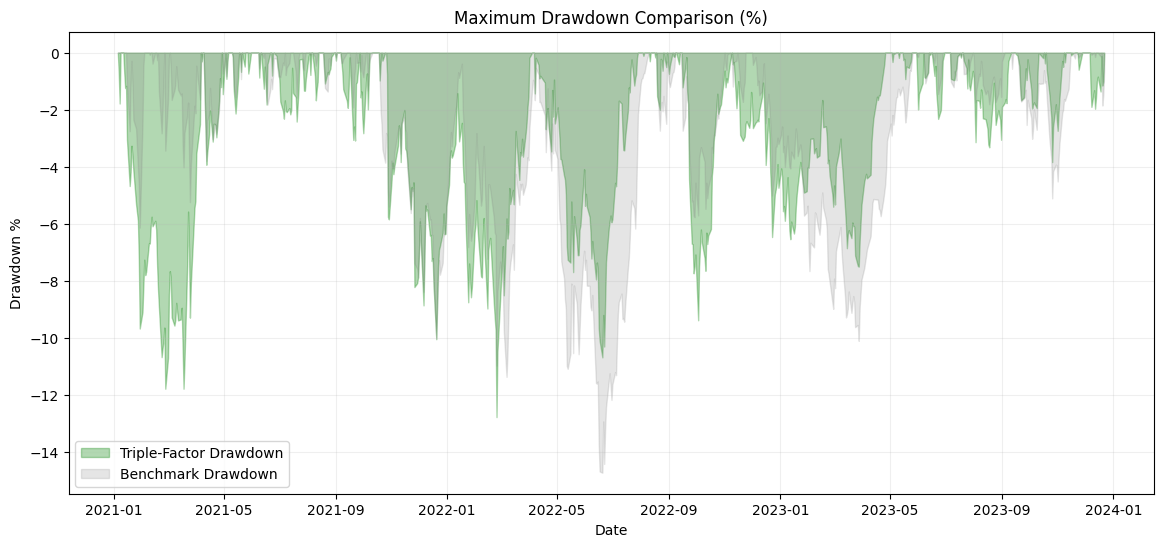

Maximum Drawdown (Strategy): -12.78%
Maximum Drawdown (Benchmark): -14.73%


In [32]:
def calculate_drawdown(cum_returns):
    # Calculate running maximum
    running_max = cum_returns.cummax()
    # Calculate drawdown as percentage decline from peak
    drawdown = (cum_returns / running_max) - 1
    return drawdown

dd_strat = calculate_drawdown(cum_strat_v2)
dd_bench = calculate_drawdown(cum_bench)

# Plot Drawdowns
plt.figure(figsize=(14, 6))
plt.fill_between(dd_strat.index, dd_strat * 100, label='Triple-Factor Drawdown', color='green', alpha=0.3)
plt.fill_between(dd_bench.index, dd_bench * 100, label='Benchmark Drawdown', color='gray', alpha=0.2)

plt.title('Maximum Drawdown Comparison (%)')
plt.ylabel('Drawdown %')
plt.xlabel('Date')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print(f"Maximum Drawdown (Strategy): {dd_strat.min()*100:.2f}%")
print(f"Maximum Drawdown (Benchmark): {dd_bench.min()*100:.2f}%")

In [33]:
def calculate_risk_metrics(strategy_cum_ret, benchmark_cum_ret, risk_free_rate=0.06):
    # Convert cumulative returns back to daily returns
    strat_rets = strategy_cum_ret.pct_change().dropna()
    bench_rets = benchmark_cum_ret.pct_change().dropna()

    # Annualization factor (approx 252 trading days)
    ann_factor = 252

    # CAGR
    days = (strategy_cum_ret.index[-1] - strategy_cum_ret.index[0]).days
    cagr = (strategy_cum_ret.iloc[-1]**(365.25/days)) - 1

    # Volatility (Annualized)
    vol = strat_rets.std() * np.sqrt(ann_factor)

    # Sharpe Ratio
    sharpe = (cagr - risk_free_rate) / vol

    # Sortino Ratio (Downside Volatility only)
    downside_rets = strat_rets[strat_rets < 0]
    downside_vol = downside_rets.std() * np.sqrt(ann_factor)
    sortino = (cagr - risk_free_rate) / downside_vol

    # Max Drawdown
    max_dd = calculate_drawdown(strategy_cum_ret).min()

    return {
        'CAGR': f"{cagr*100:.2f}%",
        'Ann. Volatility': f"{vol*100:.2f}%",
        'Sharpe Ratio': round(sharpe, 2),
        'Sortino Ratio': round(sortino, 2),
        'Max Drawdown': f"{max_dd*100:.2f}%"
    }

# Compile metrics for all portfolios
metrics = {
    'Triple-Factor Strategy': calculate_risk_metrics(cum_strat_v2, cum_bench),
    'Momentum Factor': calculate_risk_metrics(cum_mom, cum_bench),
    'Low Vol Factor': calculate_risk_metrics(cum_vol, cum_bench),
    'Value Factor': calculate_risk_metrics(cum_val, cum_bench),
    'Universe Benchmark': calculate_risk_metrics(cum_bench, cum_bench)
}

metrics_df = pd.DataFrame(metrics).T
display(metrics_df)

,CAGR,Ann. Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown
Triple-Factor Strategy,27.16%,15.70%,1.35,1.96,-12.78%
Momentum Factor,33.47%,23.01%,1.19,1.56,-18.52%
Low Vol Factor,28.70%,15.01%,1.51,2.54,-24.37%
Value Factor,35.09%,16.80%,1.73,2.48,-14.01%
Universe Benchmark,24.48%,14.31%,1.29,1.72,-14.73%


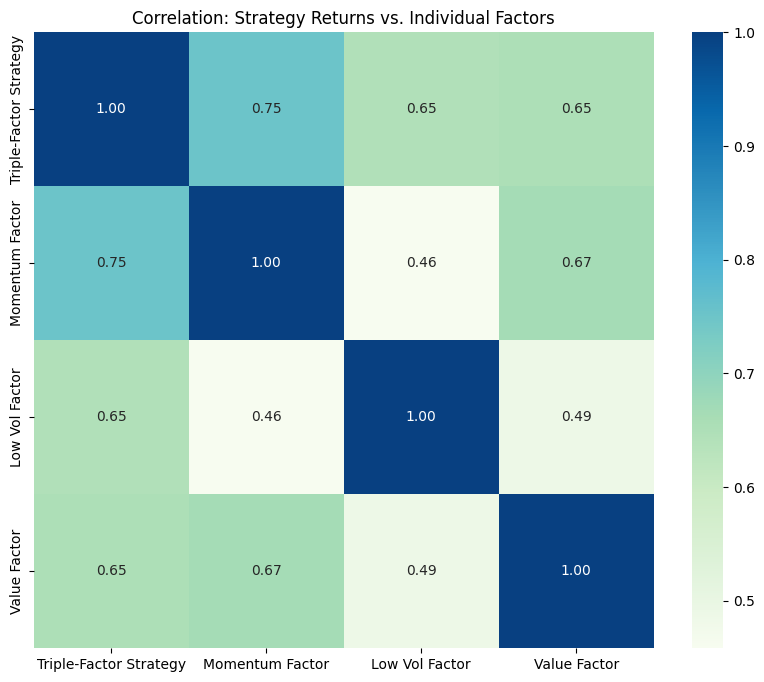

,Triple-Factor Strategy
Triple-Factor Strategy,1.000000
Momentum Factor,0.751094
Value Factor,0.651105
Low Vol Factor,0.645566


In [34]:
import pandas as pd

# Extract daily returns from cumulative returns
strat_daily = cum_strat_v2.pct_change()
mom_daily = cum_mom.pct_change()
vol_daily = cum_vol.pct_change()
val_daily = cum_val.pct_change()

# Combine into a single DataFrame for correlation analysis
returns_comparison = pd.DataFrame({
    'Triple-Factor Strategy': strat_daily,
    'Momentum Factor': mom_daily,
    'Low Vol Factor': vol_daily,
    'Value Factor': val_daily
}).dropna()

# Calculate correlation matrix
strategy_factor_corr = returns_comparison.corr()

# Visualize with a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(strategy_factor_corr, annot=True, cmap='GnBu', fmt='.2f')
plt.title('Correlation: Strategy Returns vs. Individual Factors')
plt.show()

display(strategy_factor_corr[['Triple-Factor Strategy']].sort_values(by='Triple-Factor Strategy', ascending=False))

## 📊 Strategy Dashboard: Nifty 50 Triple-Factor Model
This dashboard summarizes the performance of the Momentum + Low Volatility + Value strategy and identifies the current top picks for the next rebalance period.

In [35]:
from IPython.display import display, HTML

# 1. Performance Summary Table
perf_summary = metrics_df.loc[['Triple-Factor Strategy', 'Universe Benchmark']]

# 2. Current Strategy Picks
latest_date = composite_score_v2.index[-1]
top_picks = composite_score_v2.loc[latest_date].nlargest(5)

# Create a clean display
print(f"STRATEGY STATUS AS OF: {latest_date.date()}")
print("-" * 50)
print("\nKEY PERFORMANCE METRICS:")
display(perf_summary)

print("\nCURRENT TOP 5 ACTIONABLE SIGNALS:")
display(pd.DataFrame({
    'Triple-Factor Score': top_picks,
    'Momentum Z': z_mom.loc[latest_date, top_picks.index],
    'Low Vol Z (Lower is better)': z_vol.loc[latest_date, top_picks.index],
    'Value PE Z (Lower is better)': z_pe_df.loc[latest_date, top_picks.index]
}))

print("\nSummary: The strategy is currently favoring stocks with strong trailing performance that haven't hit extreme valuations yet.")

STRATEGY STATUS AS OF: 2023-12-29
--------------------------------------------------

KEY PERFORMANCE METRICS:


,CAGR,Ann. Volatility,Sharpe Ratio,Sortino Ratio,Max Drawdown
Triple-Factor Strategy,27.16%,15.70%,1.35,1.96,-12.78%
Universe Benchmark,24.48%,14.31%,1.29,1.72,-14.73%



CURRENT TOP 5 ACTIONABLE SIGNALS:


,Triple-Factor Score,Momentum Z,Low Vol Z (Lower is better),Value PE Z (Lower is better)
Ticker,,,,
BAJAJ-AUTO.NS,2.616800,2.670912,0.302172,-0.248061
POWERGRID.NS,2.392758,1.113313,-0.314866,-0.964579
ITC.NS,2.334940,0.606659,-0.865479,-0.862802
ONGC.NS,2.121993,0.941165,0.082872,-1.263700
BHARTIARTL.NS,2.064406,-0.040512,-0.896188,-1.208730



Summary: The strategy is currently favoring stocks with strong trailing performance that haven't hit extreme valuations yet.


### 🏗️ Sector Exposure Analysis
Understanding sector concentration is vital for risk management. Here, we identify the industry sectors for the current top-ranked stocks.

Sector Allocation for Top 5 Picks:


,Ticker,Score,Sector
0,BAJAJ-AUTO.NS,2.616800,Consumer Cyclical
1,POWERGRID.NS,2.392758,Utilities
2,ITC.NS,2.334940,Consumer Defensive
3,ONGC.NS,2.121993,Energy
4,BHARTIARTL.NS,2.064406,Communication Services


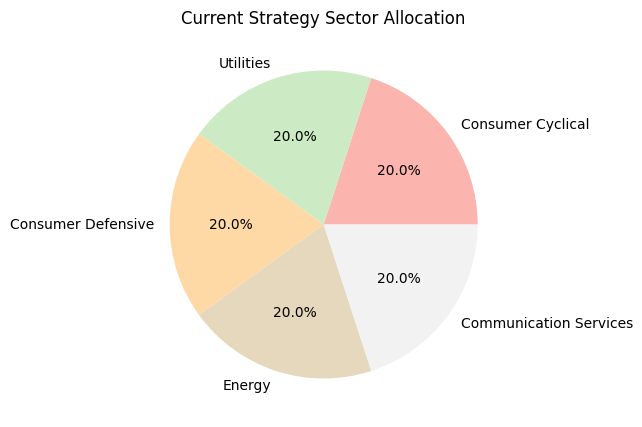

In [36]:
sector_map = {}
for ticker in top_picks.index:
    try:
        info = yf.Ticker(ticker).info
        sector_map[ticker] = info.get('sector', 'Unknown')
    except:
        sector_map[ticker] = 'N/A'

# Create a summary table
sector_df = pd.DataFrame({
    'Ticker': top_picks.index,
    'Score': top_picks.values,
    'Sector': [sector_map[t] for t in top_picks.index]
})

print("Sector Allocation for Top 5 Picks:")
display(sector_df)

# Visualize the concentration
plt.figure(figsize=(8, 5))
sector_df['Sector'].value_counts().plot(kind='pie', autopct='%1.1f%%', cmap='Pastel1')
plt.title('Current Strategy Sector Allocation')
plt.ylabel('')
plt.show()

### 📈 Individual Factor Contribution Analysis
To better understand the strategy, we compare the cumulative performance of each factor in isolation against the composite model and the equal-weighted benchmark.

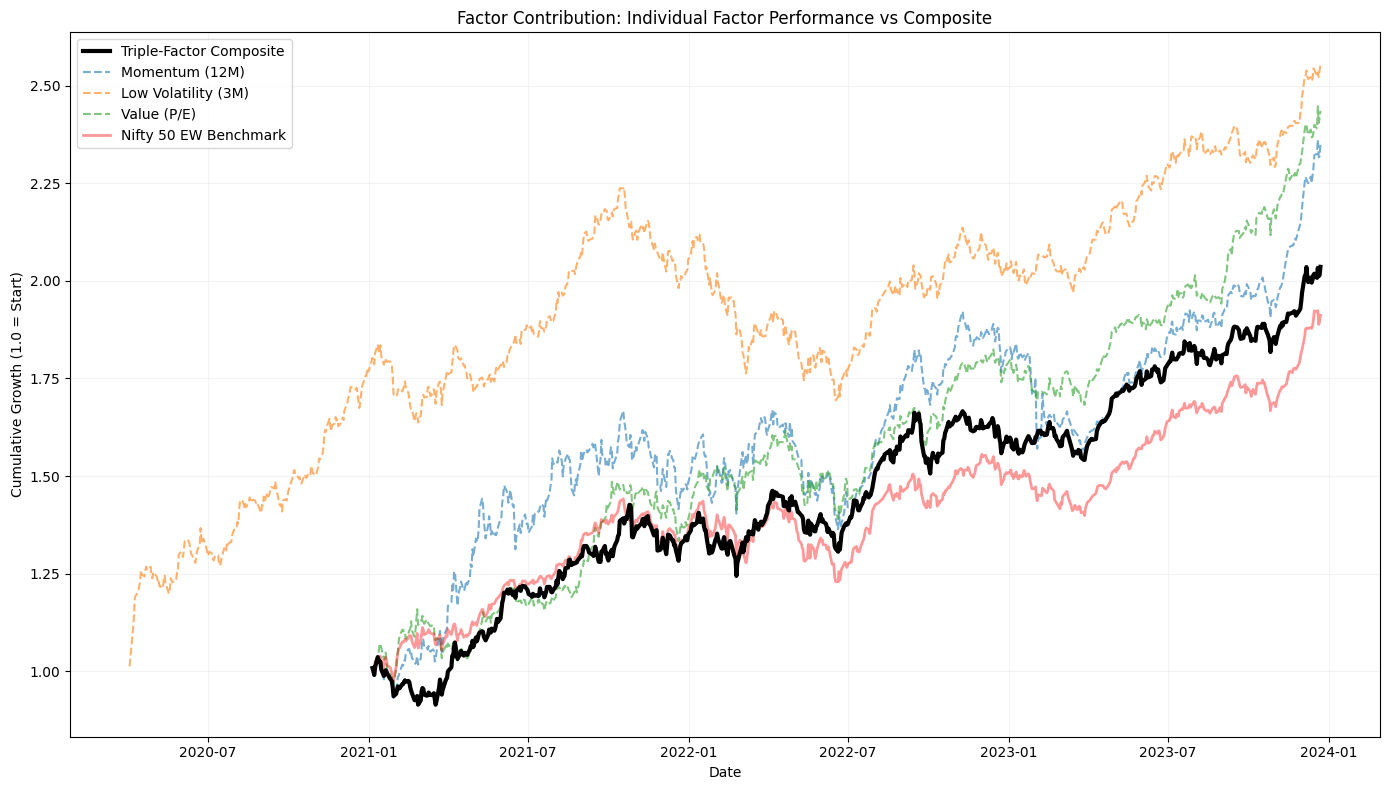

Final Cumulative Multipliers:
Low Vol Factor             2.555041
Value Factor               2.435683
Momentum Factor            2.350048
Triple-Factor Composite    2.036139
Benchmark                  1.911988
dtype: float64


In [37]:
plt.figure(figsize=(14, 8))

# Plotting all components
plt.plot(cum_strat_v2, label='Triple-Factor Composite', color='black', linewidth=3, zorder=5)
plt.plot(cum_mom, label='Momentum (12M)', alpha=0.6, linestyle='--')
plt.plot(cum_vol, label='Low Volatility (3M)', alpha=0.6, linestyle='--')
plt.plot(cum_val, label='Value (P/E)', alpha=0.6, linestyle='--')
plt.plot(cum_bench, label='Nifty 50 EW Benchmark', color='red', alpha=0.4, linewidth=2)

plt.title('Factor Contribution: Individual Factor Performance vs Composite')
plt.xlabel('Date')
plt.ylabel('Cumulative Growth (1.0 = Start)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.15)
plt.tight_layout()
plt.show()

# Summary Table of Terminal Values
terminal_values = pd.Series({
    'Triple-Factor Composite': cum_strat_v2.iloc[-1],
    'Momentum Factor': cum_mom.iloc[-1],
    'Low Vol Factor': cum_vol.iloc[-1],
    'Value Factor': cum_val.iloc[-1],
    'Benchmark': cum_bench.iloc[-1]
}).sort_values(ascending=False)

print("Final Cumulative Multipliers:")
print(terminal_values)